In [1]:
import numpy as np
import pandas as pd
import h5py


import pybel
import data_utils


import warnings

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
# path to the extracted PDBbind dataset
path = '../pdbbind/v2016/'

# Parse and clean affinity data

In [3]:
%%bash -s $path --out missing

path=$1

# Save binding affinities to csv file

echo 'pdbid,-logKd/Ki' > affinity_data.csv
cat $path/PDBbind_2016_plain_text_index/index/INDEX_general_PL_data.2016 | while read l1 l2 l3 l4 l5; do
    if [[ ! $l1 =~ "#" ]]; then
        echo $l1,$l4
    fi
done >> affinity_data.csv


# Find affinities without structural data (i.e. with missing directories)

cut -f 1 -d ',' affinity_data.csv | tail -n +2 | while read l;
    do if [ ! -e $path/general-set-except-refined/$l ] &&  [ ! -e $path/refined-set/$l ]; then
        echo $l;
    fi
done

In [4]:
missing = set(missing.split())
len(missing)

25

In [5]:
affinity_data = pd.read_csv('affinity_data.csv', comment='#')
affinity_data = affinity_data[~np.in1d(affinity_data['pdbid'], list(missing))]
affinity_data.head()

,pdbid,-logKd/Ki
0,3zzf,0.40
1,3gww,0.45
2,1w8l,0.49
3,3fqa,0.49
4,1zsb,0.60


In [6]:
# Check for NaNs

affinity_data['-logKd/Ki'].isnull().any()

False

In [7]:
# Separate core, refined, and general sets

core_set = ! grep -v '#' $path/PDBbind_2016_plain_text_index/index/INDEX_core_data.2016 | cut -f 1 -d ' '
core_set = set(core_set)

refined_set = ! grep -v '#' $path/PDBbind_2016_plain_text_index/index/INDEX_refined_data.2016 | cut -f 1 -d ' '
refined_set = set(refined_set)

general_set = set(affinity_data['pdbid'])


assert core_set & refined_set == core_set
assert refined_set & general_set == refined_set

len(general_set), len(refined_set), len(core_set)

(13283, 4057, 290)

In [8]:
affinity_data['set'] = 'general'

affinity_data.loc[np.in1d(affinity_data['pdbid'], list(refined_set - core_set)), 'set'] = 'refined'

affinity_data.loc[np.in1d(affinity_data['pdbid'], list(core_set)), 'set'] = 'core'

affinity_data.head()

,pdbid,-logKd/Ki,set
0,3zzf,0.40,general
1,3gww,0.45,general
2,1w8l,0.49,general
3,3fqa,0.49,general
4,1zsb,0.60,general


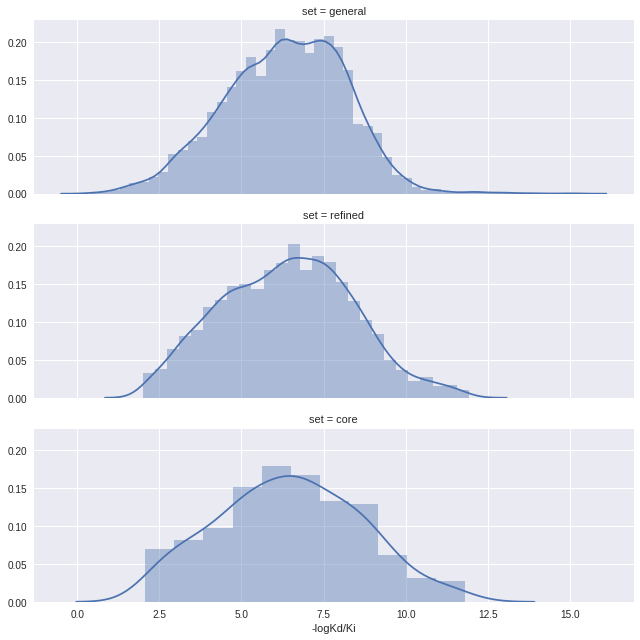

In [9]:
# Check affinity distributions

grid = sns.FacetGrid(affinity_data, row='set', row_order=['general', 'refined', 'core'], size=3, aspect=3)
grid.map(sns.distplot, '-logKd/Ki');

In [10]:
affinity_data[['pdbid']].to_csv('pdb.ids', header=False, index=False)

In [11]:
affinity_data.to_csv('affinity_data_cleaned.csv', index=False)

---

# Parse molecules

In [12]:
dataset_path = {'general': 'general-set-except-refined', 'refined': 'refined-set', 'core': 'refined-set'}

In [13]:
for dataset_name, data in affinity_data.groupby('set'):

    print(dataset_name, 'set')
    i = 0
    ds_path = dataset_path[dataset_name]
    

    with h5py.File('%s/%s.hdf' % (path, dataset_name), 'w') as f:
        for _, row in data.iterrows():

            name = row['pdbid']
            affinity = row['-logKd/Ki']

            ligand = next(pybel.readfile('mol2', '%s/%s/%s/%s_ligand.mol2' % (path, ds_path, name, name)))
            ligand.addh()

            try:
                pocket = next(pybel.readfile('pdb', '%s/%s/%s/%s_pocket.pdb' % (path, ds_path, name, name)))
            except:
                warnings.warn('no pocket for %s (%s set)' % (name, dataset_name))
                continue

            ligand.addh()

            
            ligand_coords, ligand_features = data_utils.get_features(ligand, moltype=1)            
            pocket_coords, pocket_features = data_utils.get_features(pocket, moltype=-1)
            
            centroid = ligand_coords.mean(axis=0)
            ligand_coords -= centroid
            pocket_coords -= centroid

            data = np.concatenate((np.concatenate((ligand_coords, pocket_coords)),
                                   np.concatenate((ligand_features, pocket_features))), axis=1)
            
            dataset = f.create_dataset(name, data=data, shape=data.shape, dtype='float32', compression='lzf')
            dataset.attrs['affinity'] = affinity
            i += 1

    print('prepared', i, 'complexes')

core set
prepared 290 complexes
general set
prepared 9226 complexes
refined set
prepared 3767 complexes


# Protein data

In [14]:
protein_data = pd.read_csv('%s/PDBbind_2016_plain_text_index/index/INDEX_general_PL_name.2016' % path,
                           comment='#', sep='  ', engine='python', na_values='------',
                           header=None, names=['pdbid', 'year', 'uniprotid', 'name'])

protein_data.head()

,pdbid,year,uniprotid,name
0,3eql,2008,Q9Z9H6,DNA-DIRECTED RNA POLYMERASE SUBUNIT ALPHA
1,1zyr,2005,Q5SHR6,DNA-DIRECTED RNA POLYMERASE SUBUNIT ALPHA
2,3dxj,2008,Q5SHR6,DNA-DIRECTED RNA POLYMERASE SUBUNIT ALPHA
3,4zh4,2015,P0A7Z4,DNA-DIRECTED RNA POLYMERASE SUBUNIT ALPHA
4,4zh3,2015,P0A7Z4,DNA-DIRECTED RNA POLYMERASE SUBUNIT ALPHA


In [15]:
# we assume that PDB IDs are unique
assert ~protein_data['pdbid'].duplicated().any()

protein_data = protein_data[np.in1d(protein_data['pdbid'], affinity_data['pdbid'])]

# check for missing values
protein_data.isnull().any()

pdbid        False
year         False
uniprotid     True
name          True
dtype: bool

In [16]:
protein_data[protein_data['name'].isnull()]

,pdbid,year,uniprotid,name
1158,3t8s,2011,"P29994-2INOSITOL 1,4,5-TRISPHOSPHATE RECEPTOR ...",None
5879,3nc9,2010,P50053-2KETOHEXOKINASE,None
5880,3qa2,2012,P50053-2KETOHEXOKINASE,None
5881,3q92,2012,P50053-2KETOHEXOKINASE,None
5882,3qai,2012,P50053-2KETOHEXOKINASE,None
6875,2f4j,2006,P00519 TYROSINE-PROTEIN KINASE ABL1,None


In [17]:
# fix rows with wrong separators between protein ID and name

for idx, row in protein_data[protein_data['name'].isnull()].iterrows():
    uniprotid = row['uniprotid'][:6]
    name = row['uniprotid'][7:]
    protein_data.loc[idx, ['uniprotid', 'name']] = [uniprotid, name]

protein_data.isnull().any()

pdbid        False
year         False
uniprotid     True
name         False
dtype: bool

In [18]:
protein_data.to_csv('protein_data.csv', index=False)